In [2]:
import copy
import joblib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import nibabel as nib
import numpy as np
import os
import re
import rsatoolbox as rsa
import seaborn as sns
import sys
import warnings
from collections import defaultdict
from glob import glob

from nilearn import plotting
from nilearn.image import get_data, math_img, new_img_like, threshold_img
from nilearn.regions import connected_regions

# Extend sys.path to import project modules
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')
from utils.load_cfg import load_config_instance
from utils.compile import compile_SL_rdms_files


# Functions

In [24]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label


def RDMcolormapObject(direction=1):
    cs = ['blue', 'turquoise', 'gray', 'red', 'yellow'] if direction else ['yellow', 'red', 'gray', 'turquoise', 'blue']
    return mcolors.LinearSegmentedColormap.from_list("", cs)

def plot_brainSlices(plot_img, cmap, title='', threshold = 1e-6):
 
    fig = plt.figure(figsize=(12, 3))
    plotting.plot_stat_map(
        plot_img, 
        colorbar=True, 
        threshold=threshold,
        cut_coords=[-30, -20, 0, 20, 40, 60],
        display_mode='z', 
        draw_cross=False, 
        figure=fig,
        title=title, 
        cmap=cmap,
        black_bg=False, 
        annotate=False
    )
    plt.show()

cmap = RDMcolormapObject()


def plot_all(all_subjects, config_class_name, thres= 95):

    # load data
    RDM_brain_list = []

    for subjectID in all_subjects:
        cfg = load_config_instance(config_class_name, subjectID)
        outFiles = cfg.get_outFile_names()
        RDM_brain = joblib.load(outFiles['RDM_brain'])
    
        mask = nib.load(cfg.maskFile)
        RDM_brain_nan = copy.deepcopy(RDM_brain)
        RDM_brain_nan[RDM_brain_nan == 0] = np.nan
        threshold = np.nanpercentile(RDM_brain_nan, thres)


        #%% 4) --- plot mean over subjects but omit zeros (NaN)
        mean_nan_img = new_img_like(mask, RDM_brain)
        title=f'{cfg.modelType} results subject: ' + subjectID
        plot_brainSlices(mean_nan_img, cmap = 'inferno', title=title, threshold = threshold)
        

def plot_mean(all_subjects, config_class_name, thres= 95, plotList = [1], save = False):
    cfg = load_config_instance(config_class_name, all_subjects[0])
    mask = nib.load(cfg.maskFile)

    sum_threshold_mask = np.zeros(mask.get_fdata().shape)

    for subjectID in all_subjects:

        cfg = load_config_instance(config_class_name, subjectID)
        outFiles = cfg.get_outFile_names()

        RDM_brain = joblib.load(outFiles['RDM_brain'])
        mask = nib.load(cfg.maskFile)
        RDM_brain_nan = copy.deepcopy(RDM_brain)
        RDM_brain_nan[RDM_brain_nan == 0] = np.nan

        threshold = np.nanpercentile(RDM_brain_nan, thres)
        
        mean_nan_img = new_img_like(mask, RDM_brain)
        threshold_value_img = threshold_img(mean_nan_img, 
                                            threshold=threshold, 
                                            copy=True, 
                                            copy_header=True
        )

        threshold_mask = np.zeros(threshold_value_img.get_fdata().shape)
        threshold_mask[threshold_value_img.get_fdata() > 0] = 1

        sum_threshold_mask += threshold_mask

    sum_threshold_mask_img = new_img_like(mask, sum_threshold_mask)
    if save:
        outDir = '/home/reabt/experiments/ncc/MRI/data/rsa'
        nii_filename = os.path.join(outDir, f'sum_threshold_mask_img__{cfg.modelType}__{config_class_name}__thres_{thres}__{len(all_subjects)}_subj.nii')
        nib.save(sum_threshold_mask_img, nii_filename)


    vmin = 0
    vmax = len(all_subjects)

    # --- for plotting:
    # Define your discrete color levels
    levels = np.arange(vmin, vmax + 2)  # one more than vmax for bins
    n_colors = len(levels) - 1

    # Create a discrete colormap using inferno
    base_cmap = plt.get_cmap('inferno')
    colors = base_cmap(np.linspace(0, 1, n_colors))
    cmap = ListedColormap(colors)

    # Create a normalization object to define the boundaries
    norm = BoundaryNorm(boundaries=levels, ncolors=n_colors)

    title = f'{cfg.modelType} (config {config_class_name[-2 :]}): sum of threshold mask images over {len(all_subjects)} subjects with thres = {thres}'
    # Plot with custom colormap and norm
    if 1 in plotList:
        display = plotting.plot_stat_map(
            sum_threshold_mask_img,
            display_mode="z",
            cut_coords=9,
            title=title,
            cmap=cmap,
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

    if 2 in plotList:
        display = plotting.plot_stat_map(
            sum_threshold_mask_img,
            display_mode="ortho",
            title=title,
            cbar_tick_format = "%i",
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
            cmap = 'inferno'
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

    if 3 in plotList:
        display = plotting.plot_glass_brain(
            sum_threshold_mask_img,
            display_mode="ortho",
            title=title,
            cbar_tick_format = "%i",
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
            cmap = 'inferno'
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

# show single subjects

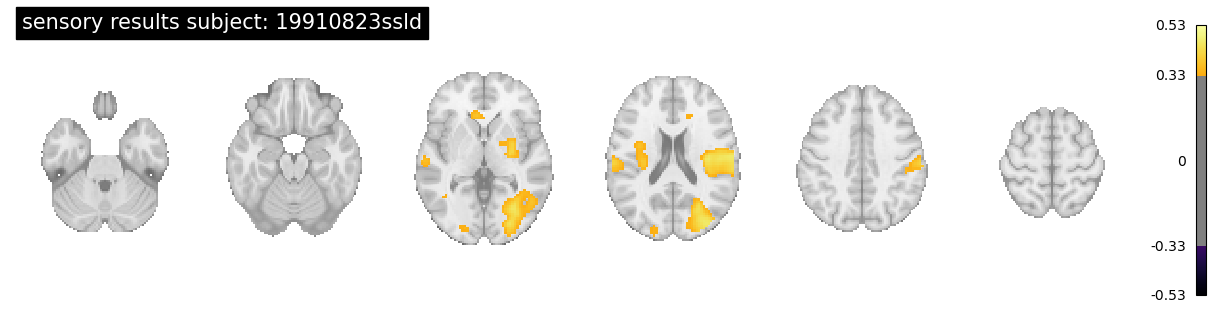

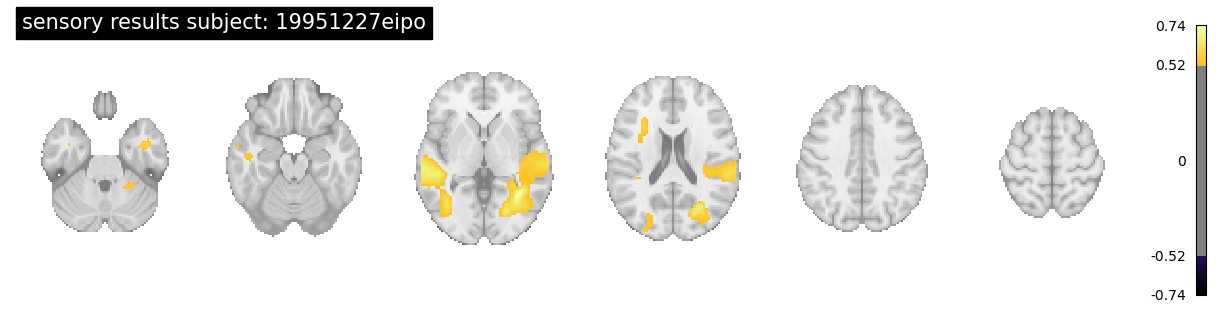

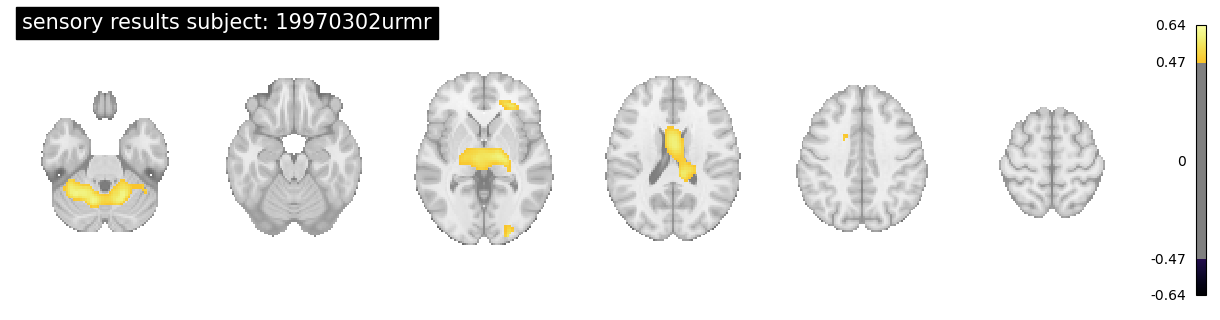

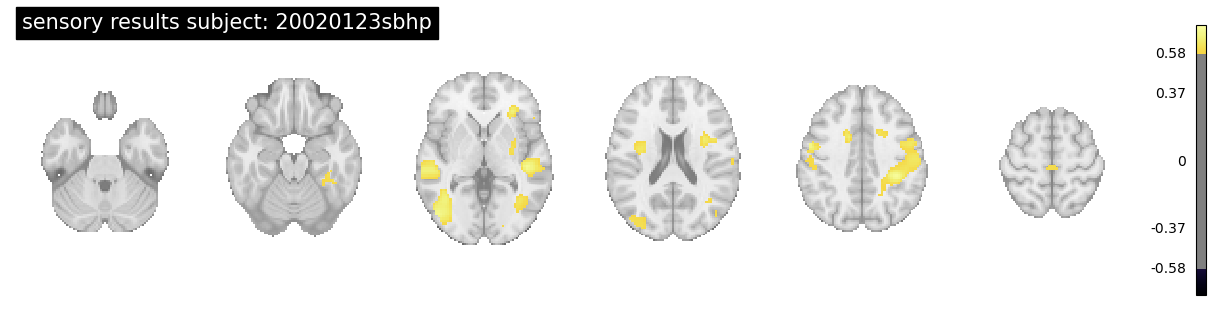

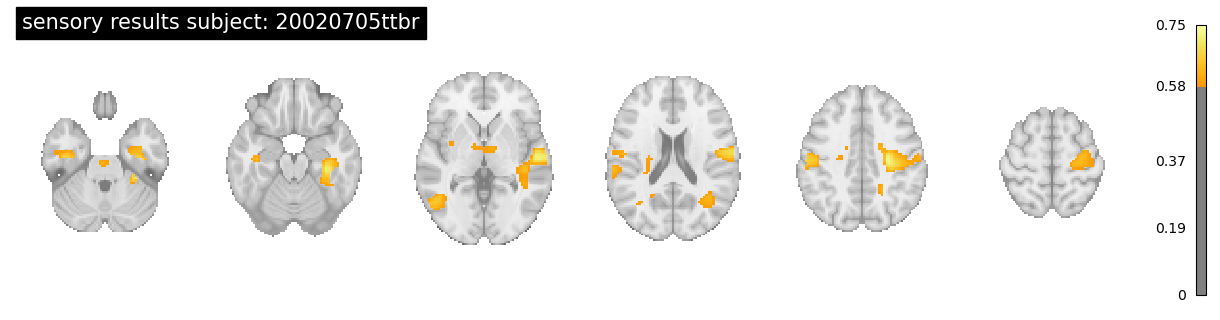

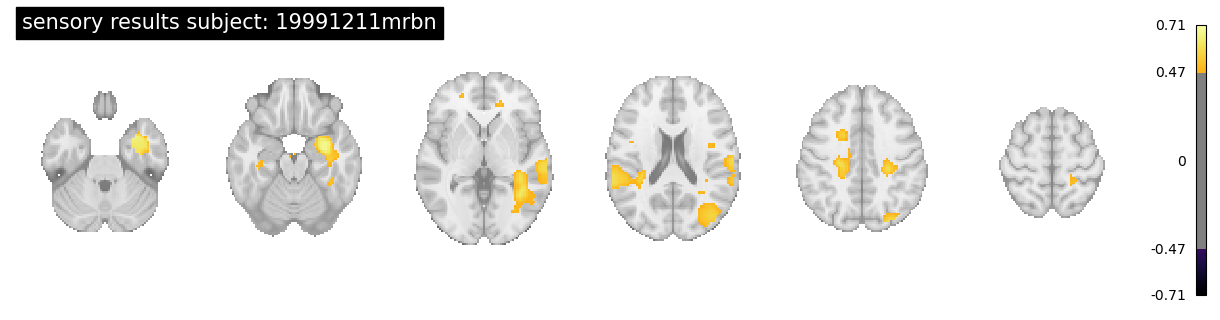

In [14]:
all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]
config_class_name = 'SensoryConfig_E2'
plot_all(all_subjects, config_class_name)


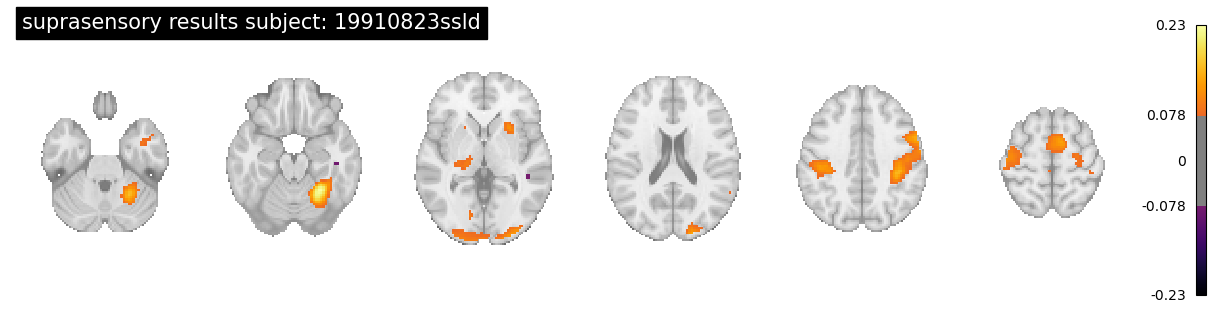

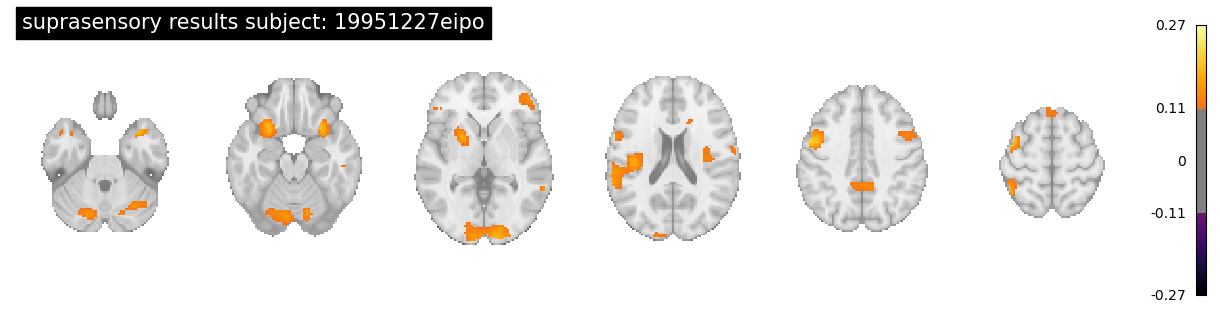

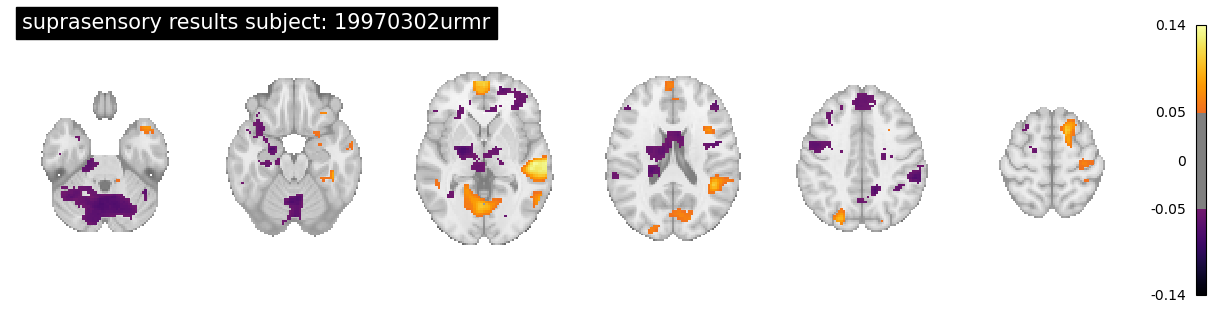

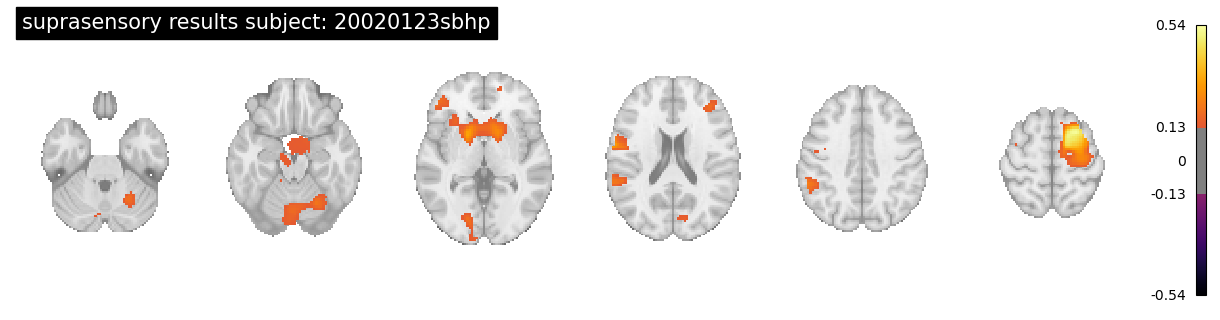

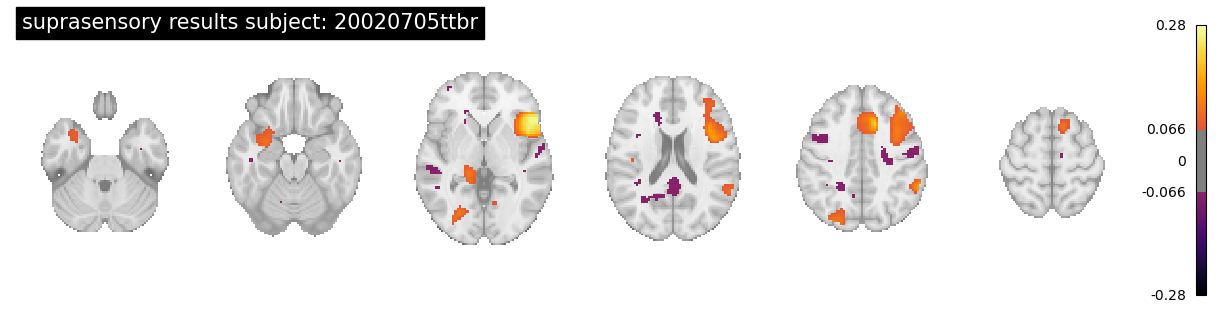

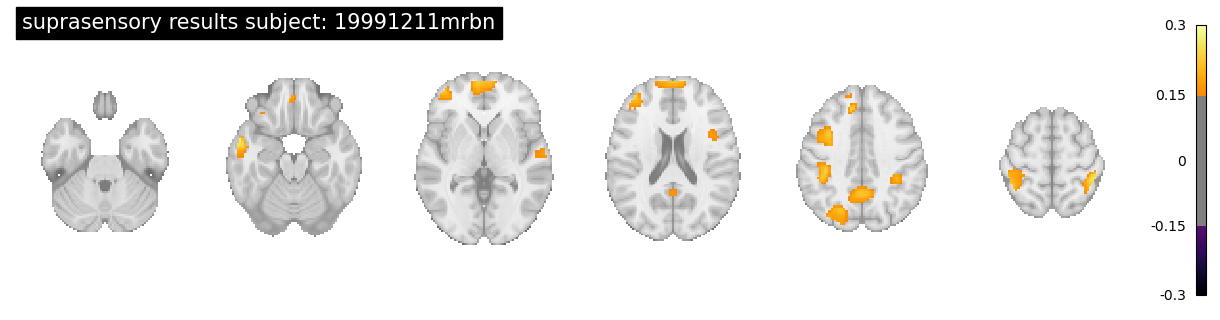

In [15]:

all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]
config_class_name = 'SensoryConfig_E4'
plot_all(all_subjects, config_class_name)


## single subject

In [7]:
# load data
config_class_name = 'SensoryConfig_E4'
thres = 95


all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]
subjectID = all_subjects[0]

RDM_brain_list = []

# for subjectID in all_subjects:

cfg = load_config_instance(config_class_name, subjectID)
outFiles = cfg.get_outFile_names()
RDM_brain = joblib.load(outFiles['RDM_brain'])

mask = nib.load(cfg.maskFile)
RDM_brain_nan = copy.deepcopy(RDM_brain)
RDM_brain_nan[RDM_brain_nan == 0] = np.nan
threshold = np.nanpercentile(RDM_brain_nan, thres)

mean_nan_img = new_img_like(mask, RDM_brain)

# easy way to filter data by threshold 
threshold_value_img = threshold_img(
    mean_nan_img, threshold= threshold, copy=True, copy_header=True
)

# binary mask including above average voxels = 1
threshold_mask = np.zeros(threshold_value_img.get_fdata().shape)
threshold_mask[threshold_value_img.get_fdata() > 0] = 1




# all subjects, sum of threshold masks

## 4 subjects

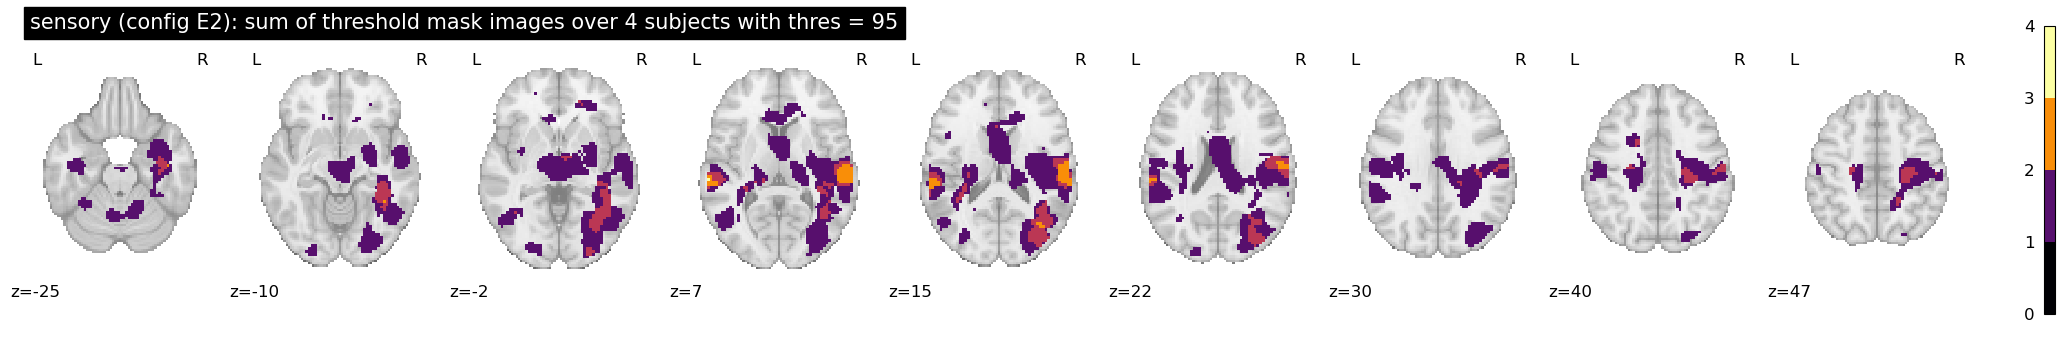

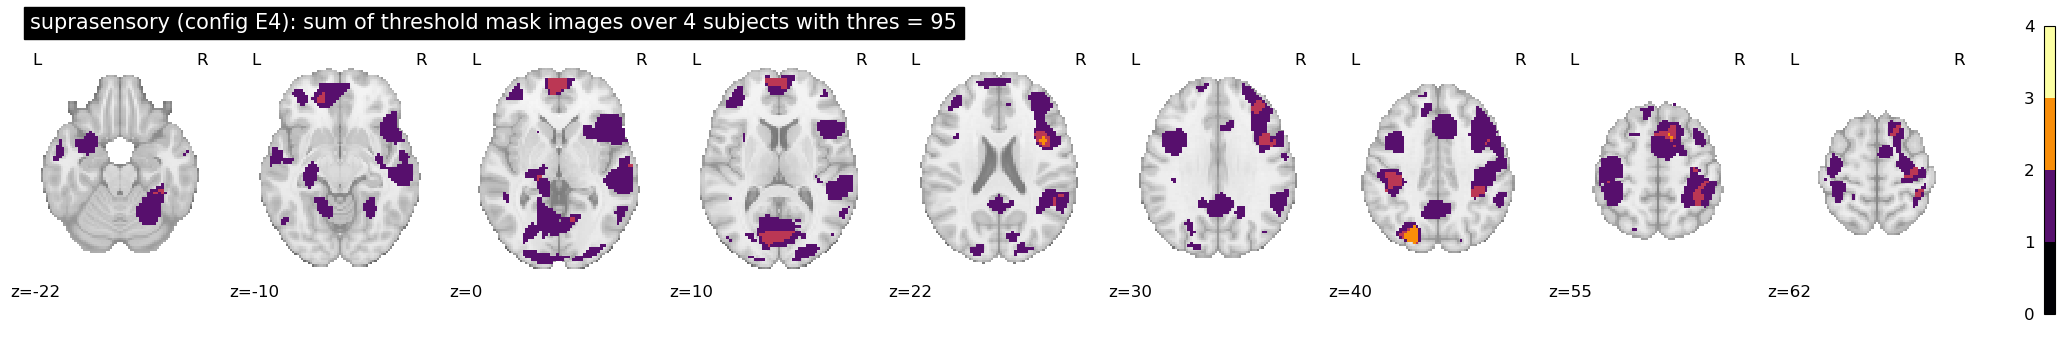

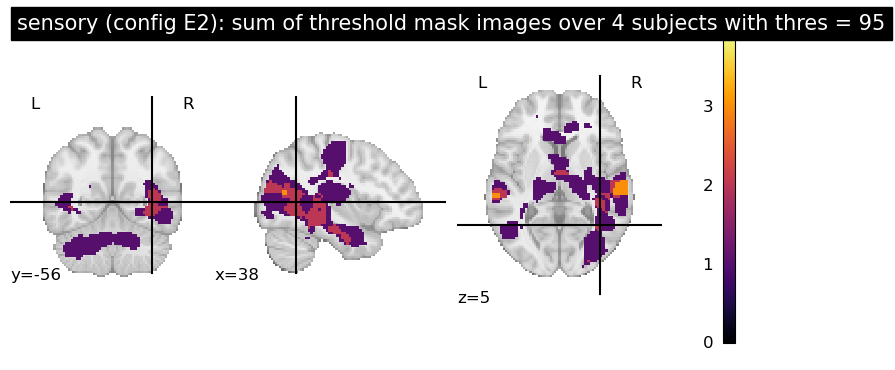

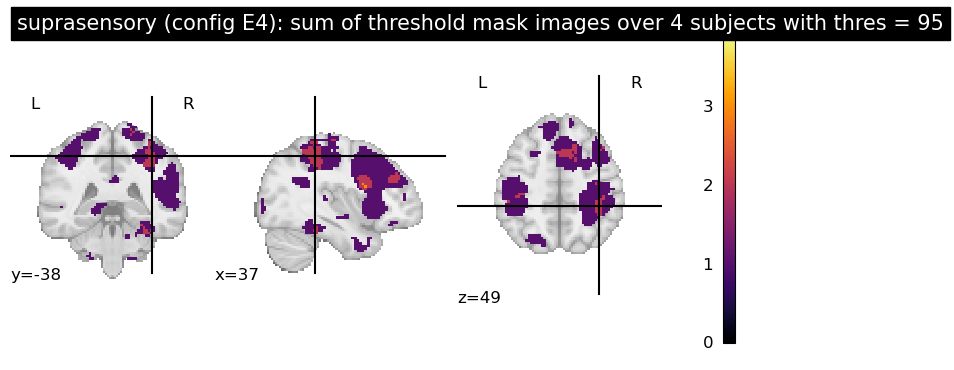

In [25]:
# --> threshold: 95%

all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=95, save = True)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=95, save = True)


config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=95, plotList=[2])

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=95, plotList=[2])

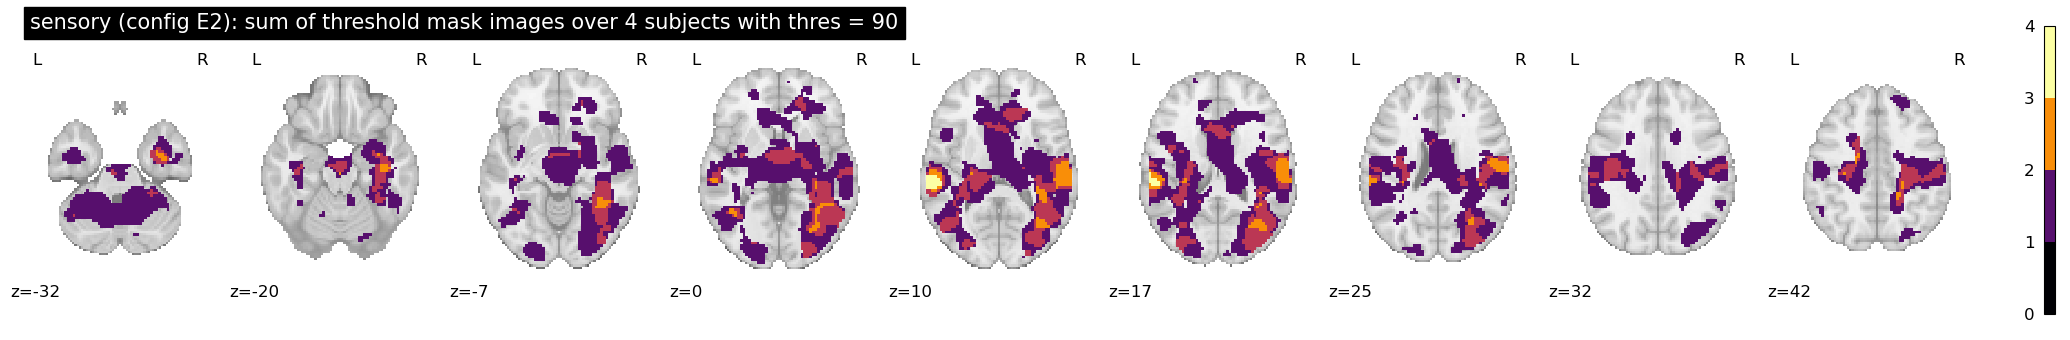

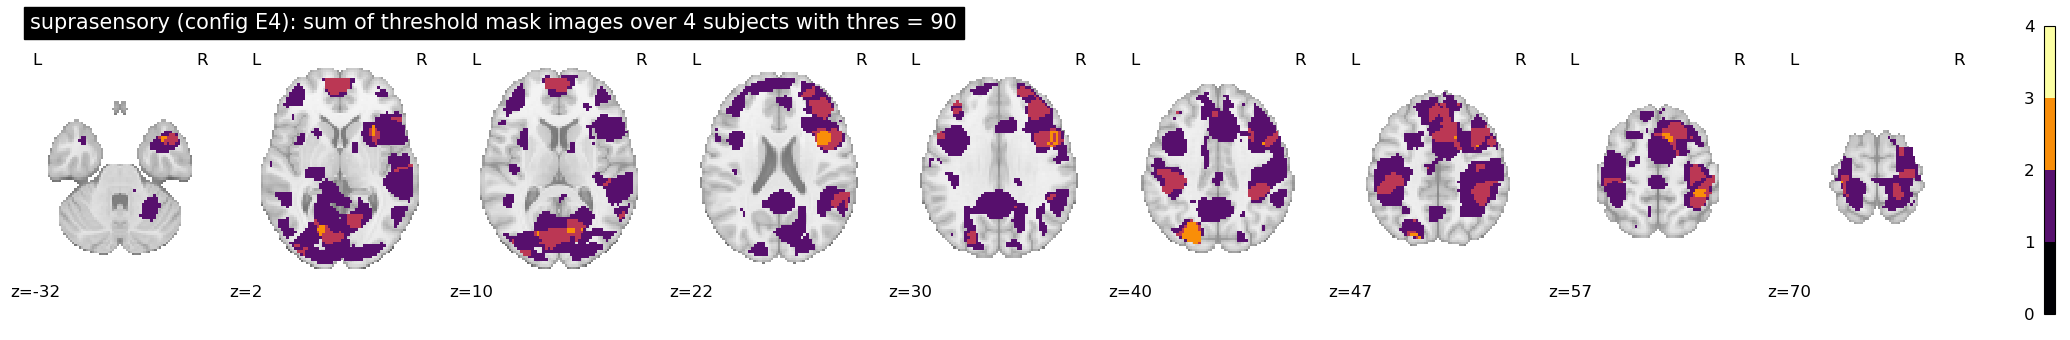

In [ ]:
# --> threshold: 90%

all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=90)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=90)

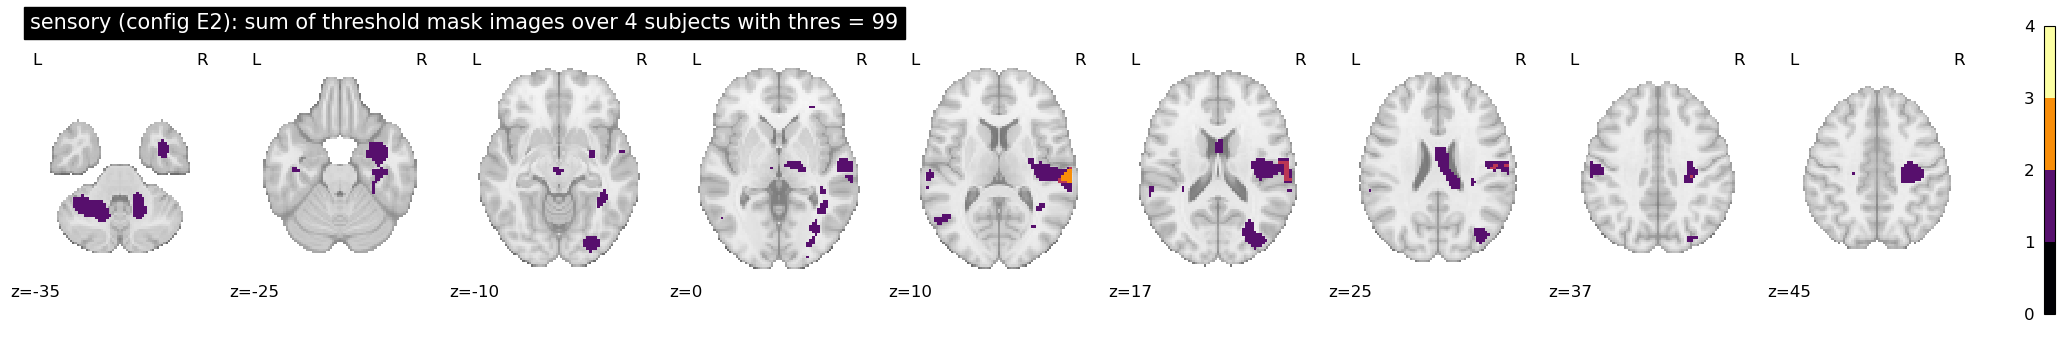

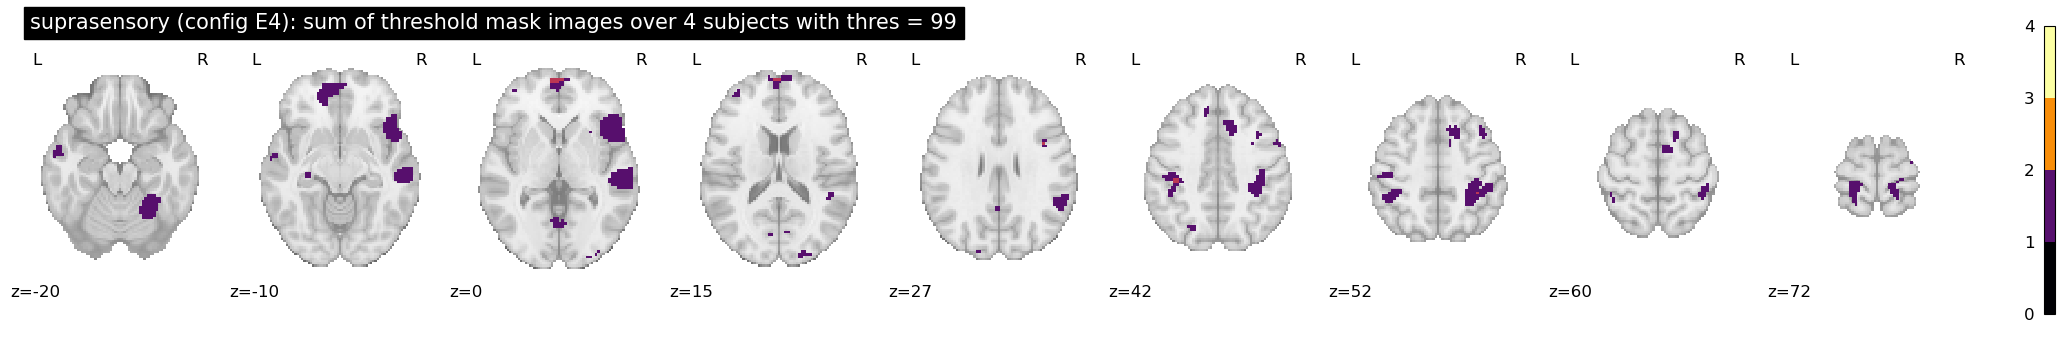

In [ ]:
# --> threshold: 99%

all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=99)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=99)

In [2]:
len('Most of the numerous studies on the conscious perception of sensory information focus on a single sensory modality. We aim to extend the perspective to a framework of supramodal neural correlates of consciousness (NCC). Using a report-based detection paradigm including visual, auditory and tactile near-threshold (NT) stimuli, we combine data from functional magnetic resonance imaging (fMRI) and magnetoencephalography (MEG) using representational similarity analysis. This rigorous methodological approach combines the strengths of both fMRI and MEG, facilitating excellent spatial resolution as well as superior temporal precision. Preliminary results on the temporal dynamics of conscious perception indicate that neural activity reflecting the pure sensory processing of stimuli precedes the activity patterns associated with conscious perception. Whereas stimulus-driven activation was predominantly observed in sensory areas contralateral to the stimulated side, activity patterns distinguishing perceived from unperceived stimuli—independent of sensory modality—were found in frontal regions and in parietal areas ipsilateral to the stimulation. These preliminary findings suggest the involvement of a fronto-parietal network in the transition from modality-specific sensory processing to integrative supramodal conscious perception.')

1342

## 6 subjects


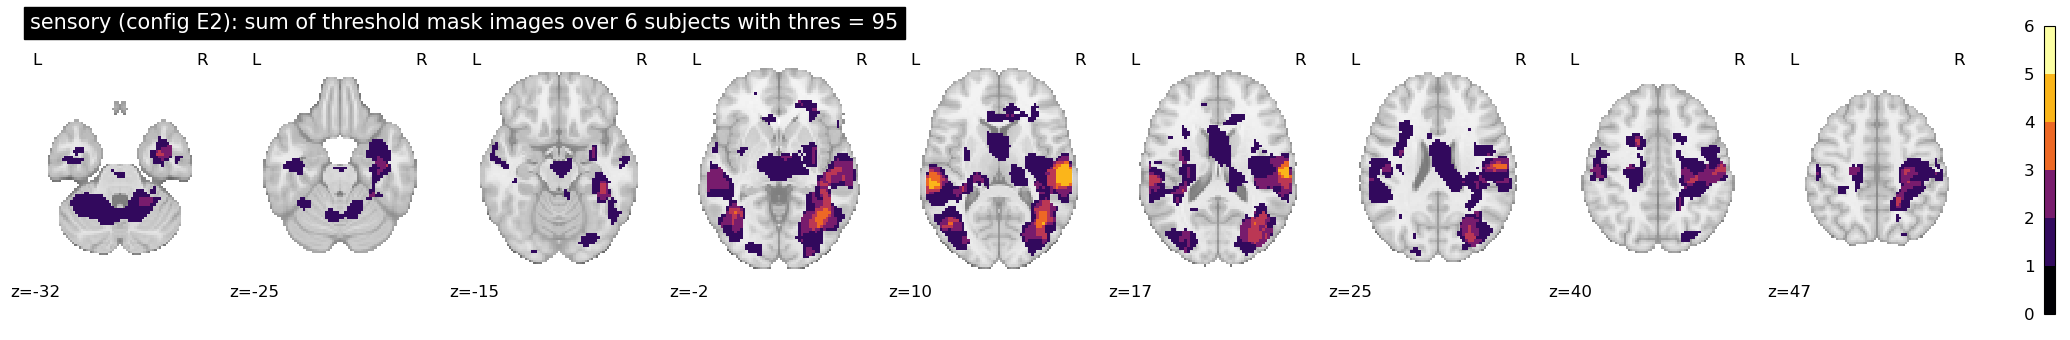

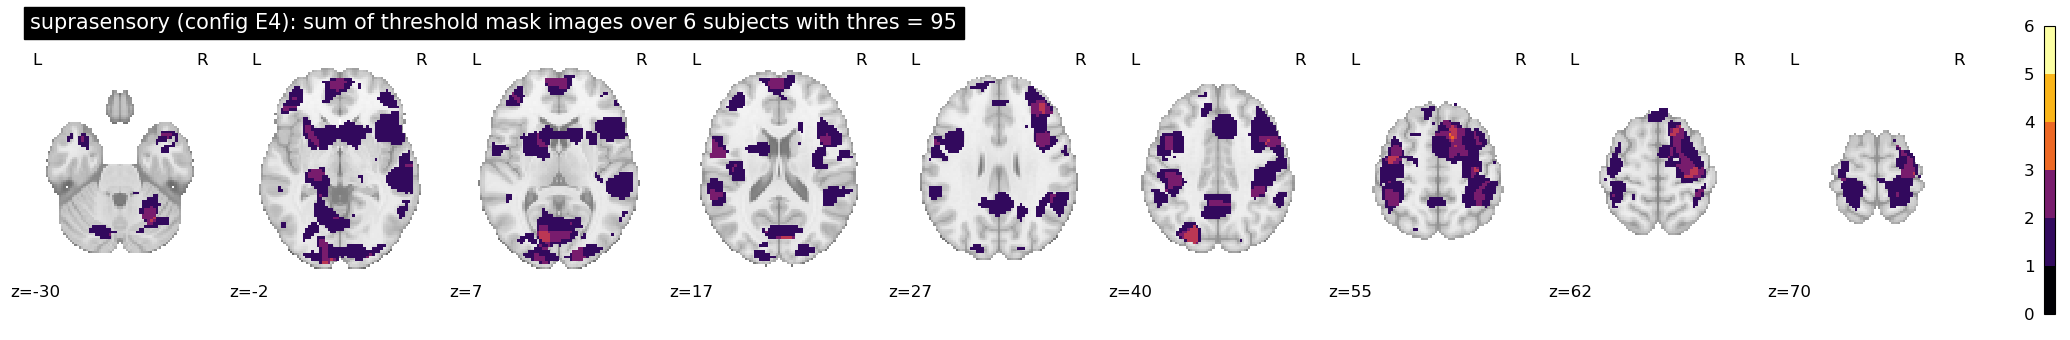

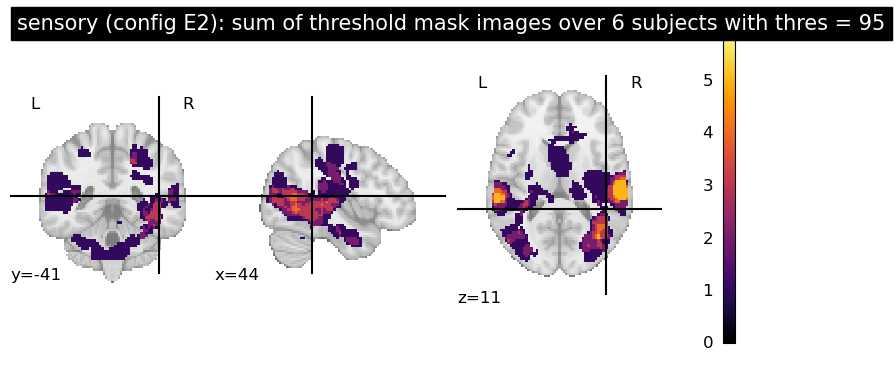

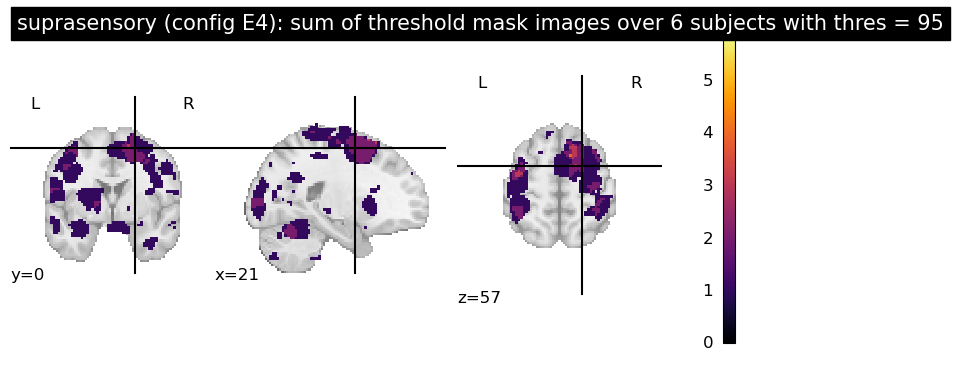

In [26]:
# --> threshold: 95%

all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=95, save = True)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=95, save = True)


config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=95, plotList=[2])

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=95, plotList=[2])